# THREXIA — AI-Based Insider Threat Detection
### Phase 2: Complete Implementation using Kaggle Corporate Dataset

**National University of Computer and Emerging Sciences (FAST-NU), Lahore**

| Name | Roll Number | Sub-section |
|------|------------|-------------|
| Anas Naveed Butt | 23L-0764 | 6-D |
| Muhammad Usman Saboor | 23L-0813 | 6-D |
| Ibrahim Rashid | 23L-0741 | 6-D |
| Mohib Ali Khattak | 23L-0763 | 6-D |

**Dataset:** Insider Threat Dataset for Corporate Environments  
**Source:** https://www.kaggle.com/datasets/ahmeduzaki/insider-threat-dataset-for-corporate-environments


## The reason for using this data set is mentioned at the end of this file

---
##  Section 1 — Install Dependencies & Imports

In [1]:
import subprocess, sys

packages = [
    "kagglehub[pandas-datasets]",
    "pandas", "numpy", "scikit-learn",
    "matplotlib", "seaborn", "joblib", "imbalanced-learn"
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("All packages installed.")

All packages installed.


In [2]:
# ============================================================
# THREXIA — Core Imports
import os
import warnings
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import kagglehub
from kagglehub import KaggleDatasetAdapter

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_auc_score,
)

# ── Global settings ──────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="darkgrid", palette="husl")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

MODEL_DIR = Path("./models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Imports successful.")

Imports successful.


---
## Section 2 — Load Dataset from Kaggle


In [3]:
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [4]:
# ============================================================
# Load the Corporate Environments Insider Threat Dataset
# ============================================================
DATASET_ID = "ahmeduzaki/insider-threat-dataset-for-corporate-environments"

print(f"[INFO] Downloading dataset: {DATASET_ID}")
print("       This may take a moment on first download (cached after)...")

try:
    # Step 1: Try loading directly as a single-file dataset
    df_raw = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        DATASET_ID,
        "",
    )
    print(f"Dataset loaded directly.")

except Exception as e:
    print(f"Direct load failed: {e}")
    print("[INFO] Trying file discovery fallback...")

    # Step 2: Download and discover available files
    import kagglehub as kh
    path = kh.dataset_download(DATASET_ID)
    print(f"[INFO] Downloaded to: {path}")

    # Find all CSV files
    csv_files = []
    for root, dirs, files in os.walk(path):
        for f in files:
            full = os.path.join(root, f)
            print(f"  Found: {full}")
            if f.endswith(".csv"):
                csv_files.append(full)

    if not csv_files:
        raise FileNotFoundError("No CSV files found. Check dataset contents above.")

    # Load the largest CSV (most likely the main data file)
    csv_files.sort(key=os.path.getsize, reverse=True)
    print(f"\n[INFO] Loading: {csv_files[0]}")
    df_raw = pd.read_csv(csv_files[0], low_memory=False)

print(f"\nShape      : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Columns    : {list(df_raw.columns)}")
print("\n First 3 rows:")
df_raw.head(3)

[INFO] Downloading dataset: ahmeduzaki/insider-threat-dataset-for-corporate-environments
       This may take a moment on first download (cached after)...
Direct load failed: Unsupported file extension: ''. Supported file extensions are: .csv, .tsv, .json, .jsonl, .xml, .parquet, .feather, .sqlite, .sqlite3, .db, .db3, .s3db, .dl3, .xls, .xlsx, .xlsm, .xlsb, .odf, .ods, .odt
[INFO] Trying file discovery fallback...


100%|██████████| 609k/609k [00:00<00:00, 62.0MB/s]

Extracting files...
[INFO] Downloaded to: /root/.cache/kagglehub/datasets/ahmeduzaki/insider-threat-dataset-for-corporate-environments/versions/1
  Found: /root/.cache/kagglehub/datasets/ahmeduzaki/insider-threat-dataset-for-corporate-environments/versions/1/insider_threat_clean_dataset.csv

[INFO] Loading: /root/.cache/kagglehub/datasets/ahmeduzaki/insider-threat-dataset-for-corporate-environments/versions/1/insider_threat_clean_dataset.csv



Shape      : 118,614 rows × 22 columns
Columns    : ['employee_department', 'employee_campus', 'employee_position', 'employee_seniority_years', 'is_contractor', 'employee_classification', 'has_foreign_citizenship', 'has_criminal_record', 'has_medical_history', 'employee_origin_country', 'total_printed_pages', 'num_printed_pages_off_hours', 'total_files_burned', 'burned_from_other', 'is_abroad', 'trip_day_number', 'hostility_country_level', 'num_entries', 'num_unique_campus', 'late_exit_flag', 'entry_during_weekend', 'is_malicious']

 First 3 rows:


,employee_department,employee_campus,employee_position,employee_seniority_years,is_contractor,employee_classification,has_foreign_citizenship,has_criminal_record,has_medical_history,employee_origin_country,total_printed_pages,num_printed_pages_off_hours,total_files_burned,burned_from_other,is_abroad,trip_day_number,hostility_country_level,num_entries,num_unique_campus,late_exit_flag,entry_during_weekend,is_malicious
0,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,0,0,4,0,0,0.0000,0,1,1,0,1,0
1,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,0,0,0,0,0,0.0000,0,1,1,0,0,0
2,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,0,0,2,0,0,0.0000,0,1,1,0,0,0


---
## Section 3 — Automated Column Discovery & Mapping

Since the exact column names in this dataset may vary, the cell below **auto-detects** which columns correspond to which roles (label, numeric features, categorical columns) using pattern matching. It then prints the full mapping so you can verify it before training.

In [5]:
# ============================================================
# Show full dataset info before doing anything
# ============================================================
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nShape  : {df_raw.shape}")
print(f"Memory : {df_raw.memory_usage(deep=True).sum() / 1e6:.2f} MB")
print("\nColumn dtypes:")
print(df_raw.dtypes)
print("\nMissing values per column:")
print(df_raw.isnull().sum())
print("\nBasic statistics:")
df_raw.describe(include="all")

DATASET OVERVIEW

Shape  : (118614, 22)
Memory : 46.84 MB

Column dtypes:
employee_department             object
employee_campus                 object
employee_position               object
employee_seniority_years         int64
is_contractor                    int64
employee_classification          int64
has_foreign_citizenship          int64
has_criminal_record              int64
has_medical_history              int64
employee_origin_country         object
total_printed_pages              int64
num_printed_pages_off_hours      int64
total_files_burned               int64
burned_from_other                int64
is_abroad                        int64
trip_day_number                float64
hostility_country_level          int64
num_entries                      int64
num_unique_campus                int64
late_exit_flag                   int64
entry_during_weekend             int64
is_malicious                     int64
dtype: object

Missing values per column:
employee_department       

,employee_department,employee_campus,employee_position,employee_seniority_years,is_contractor,employee_classification,has_foreign_citizenship,has_criminal_record,has_medical_history,employee_origin_country,total_printed_pages,num_printed_pages_off_hours,total_files_burned,burned_from_other,is_abroad,trip_day_number,hostility_country_level,num_entries,num_unique_campus,late_exit_flag,entry_during_weekend,is_malicious
count,118614,118614,118614,118614.0000,118614.0000,118614.0000,118614.0000,118614.0000,118614.0000,118614,118614.0000,118614.0000,118614.0000,118614.0000,118614.0000,118614.0000,118614.0000,118614.0000,118614.0000,118614.0000,118614.0000,118614.0000
unique,11,3,48,NaN,NaN,NaN,NaN,NaN,NaN,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,R&D Department,Campus C,Secretary,NaN,NaN,NaN,NaN,NaN,NaN,Israel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,23796,40156,20515,NaN,NaN,NaN,NaN,NaN,NaN,49972,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,12.3715,0.1406,1.8897,0.1632,0.0493,0.1513,NaN,13.7085,0.5839,9.3808,0.0072,0.0418,0.2234,0.0056,0.7463,0.5979,0.0000,0.0506,0.0538
std,NaN,NaN,NaN,7.1954,0.3476,0.7499,0.3695,0.2165,0.3584,NaN,25.0712,4.2935,19.7241,0.0847,0.2002,1.2703,0.1107,0.7388,0.5344,0.0000,0.2192,0.2257
min,NaN,NaN,NaN,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,NaN,NaN,NaN,7.0000,0.0000,1.0000,0.0000,0.0000,0.0000,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,NaN,NaN,NaN,12.0000,0.0000,2.0000,0.0000,0.0000,0.0000,NaN,5.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000
75%,NaN,NaN,NaN,18.0000,0.0000,2.0000,0.0000,0.0000,0.0000,NaN,18.0000,0.0000,7.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000


In [10]:
# ============================================================
# Auto-detect label column and feature columns
# ============================================================

def detect_label_column(df: pd.DataFrame) -> str:
    """
    Find the ground-truth label column by searching for common naming patterns.
    Returns the column name or raises an error with available columns listed.
    """
    # Common label column names in insider threat datasets
    candidates = [
        "label", "Label", "LABEL",
        "insider", "Insider", "INSIDER",
        "threat", "Threat", "is_threat",
        "malicious", "Malicious", "is_malicious",
        "anomaly", "Anomaly", "is_anomaly",
        "class", "Class", "target", "Target",
        "attack", "Attack", "fraud", "Fraud",
    ]
    for col in candidates:
        if col in df.columns:
            unique_vals = df[col].dropna().unique()
            print(f" Label column found: '{col}'")
            print(f"  Unique values: {unique_vals[:10]}")
            return col

    # Fallback: find any binary/low-cardinality integer column
    for col in df.select_dtypes(include=["int64", "int32", "float64"]).columns:
        n_unique = df[col].nunique()
        if n_unique == 2:
            print(f" No standard label column found.")
            print(f"   Using binary column as label: '{col}' (values: {df[col].unique()})")
            return col

    print(f" No label column detected. Available columns:\n{list(df.columns)}")
    raise ValueError("Could not detect label column. Set LABEL_COL manually below.")


def build_feature_cols(df: pd.DataFrame, label_col: str,
                        exclude_patterns: list = None) -> list:
    """
    Auto-select numeric feature columns, excluding the label and
    any ID/timestamp columns that are not useful for ML.
    """
    exclude_patterns = exclude_patterns or [
        "id", "user", "name", "date", "time", "timestamp",
        "week", "day", "month", "year", "index", "session",
    ]

    numeric_cols = df.select_dtypes(include=["int64", "int32", "float64"]).columns.tolist()
    feature_cols = []

    for col in numeric_cols:
        if col == label_col:
            continue
        col_lower = col.lower()
        if any(pat in col_lower for pat in exclude_patterns):
            print(f"  ↳ Skipping ID/time column: '{col}'")
            continue
        feature_cols.append(col)

    return feature_cols


# ── Run auto-detection ───────────────────────────────────────
print("\n" + "=" * 55)
print(" COLUMN AUTO-DETECTION")
print("=" * 55)

# ▼▼ OVERRIDE HERE if auto-detection is wrong ▼▼
# LABEL_COL = "label"          # ← Manually set label column name
# FEATURE_COLS = ["col1", ...]  # ← Manually set feature column names

LABEL_COL = detect_label_column(df_raw)
print()
FEATURE_COLS = build_feature_cols(df_raw, LABEL_COL)

print(f"\nFeatures selected ({len(FEATURE_COLS)}):")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"   {i:2d}. {col}")


 COLUMN AUTO-DETECTION
 Label column found: 'is_malicious'
  Unique values: [0 1]

  ↳ Skipping ID/time column: 'employee_seniority_years'
  ↳ Skipping ID/time column: 'trip_day_number'
  ↳ Skipping ID/time column: 'entry_during_weekend'

Features selected (14):
    1. is_contractor
    2. employee_classification
    3. has_foreign_citizenship
    4. has_criminal_record
    5. has_medical_history
    6. total_printed_pages
    7. num_printed_pages_off_hours
    8. total_files_burned
    9. burned_from_other
   10. is_abroad
   11. hostility_country_level
   12. num_entries
   13. num_unique_campus
   14. late_exit_flag


In [11]:
# ============================================================
# Encode label to binary 0/1 if it is not already
# (handles string labels like 'normal'/'malicious', 0/1, 1/-1)
# ============================================================

def normalise_labels(series: pd.Series) -> pd.Series:
    """
    Convert any label format to binary int: 0 = normal, 1 = malicious.
    Handles: {0,1}, {-1,1}, {'normal','malicious'}, {'0','1'}, {'True','False'}
    """
    vals = series.dropna().unique()

    # Already 0/1
    if set(vals).issubset({0, 1, 0.0, 1.0}):
        return series.astype(int)

    # Isolation Forest style: -1 anomaly, +1 normal
    if set(vals).issubset({-1, 1}):
        return (series == -1).astype(int)

    # String labels — encode the minority class as 1
    le = LabelEncoder()
    encoded = le.fit_transform(series.astype(str))
    # The minority class should be label=1 (malicious)
    counts = pd.Series(encoded).value_counts()
    majority_encoded = counts.idxmax()
    if majority_encoded == 1:
        encoded = 1 - encoded  # flip so majority = 0
    print(f"   Label mapping: {dict(zip(le.classes_, range(len(le.classes_))))}")
    print(f"   Majority class (normal) mapped to → 0")
    return pd.Series(encoded, index=series.index)


df_raw["label"] = normalise_labels(df_raw[LABEL_COL])

n_normal    = (df_raw["label"] == 0).sum()
n_malicious = (df_raw["label"] == 1).sum()
total       = len(df_raw)

print(f"\n Class distribution after encoding:")
print(f"   Normal    (0): {n_normal:>8,}  ({n_normal/total*100:.2f}%)")
print(f"   Malicious (1): {n_malicious:>8,}  ({n_malicious/total*100:.2f}%)")
print(f"   Total        : {total:>8,}")


 Class distribution after encoding:
   Normal    (0):  112,228  (94.62%)
   Malicious (1):    6,386  (5.38%)
   Total        :  118,614


---
## Section 4 — Data Cleaning & Preprocessing
We apply the standard preprocessing pipeline described in the THREXIA proposal:
1. Remove duplicates and rows with excessive missing values
2. Impute remaining missing values with column medians
3. Encode any remaining categorical features
4. Scale all numeric features using `StandardScaler`
5. Perform a stratified 80/20 train/test split

In [12]:
# ============================================================
# Data Cleaning
# ============================================================

df = df_raw.copy()

# ── 1. Drop duplicate rows ───────────────────────────────────
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Duplicates removed  : {before - len(df):,} rows")

# ── 2. Drop rows where >50% of features are missing ─────────
before = len(df)
threshold = len(FEATURE_COLS) * 0.5
df = df[df[FEATURE_COLS].isnull().sum(axis=1) <= threshold]
print(f"Sparse rows removed : {before - len(df):,} rows")

# ── 3. Impute remaining missing values with column medians ───
for col in FEATURE_COLS:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"  Imputed '{col}' with median={median_val:.4f}")

# ── 4. Encode categorical feature columns if any ────────────
cat_in_features = df[FEATURE_COLS].select_dtypes(include=["object", "bool"]).columns.tolist()
for col in cat_in_features:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))
    print(f"  Encoded categorical column: '{col}'")

print(f"\n Cleaned dataset : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Missing values  : {df[FEATURE_COLS].isnull().sum().sum()}  (should be 0)")

Duplicates removed  : 0 rows
Sparse rows removed : 0 rows

 Cleaned dataset : 118,614 rows × 23 columns
   Missing values  : 0  (should be 0)


In [13]:
# ============================================================
# Train / Test Split + Feature Scaling
# ============================================================
X = df[FEATURE_COLS].values
y = df["label"].values

# Stratified split preserves the class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

# Fit scaler on TRAINING data only — prevents data leakage
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)      # Apply same transform to test set

# Contamination rate = fraction of malicious samples in training data
CONTAMINATION = max(0.01, y_train.mean())
CONTAMINATION = min(CONTAMINATION, 0.49)  # Isolation Forest cap

print("Data Split Summary")
print(f"   Training samples     : {X_train_s.shape[0]:>8,}")
print(f"   Test samples         : {X_test_s.shape[0]:>8,}  (hold-out, never seen in training)")
print(f"   Features             : {X_train_s.shape[1]}")
print(f"   Train class balance  : Normal={np.bincount(y_train)[0]:,} | Malicious={np.bincount(y_train)[1]:,}")
print(f"   Contamination rate   : {CONTAMINATION:.4f}  ({CONTAMINATION*100:.2f}%)")

Data Split Summary
   Training samples     :   94,891
   Test samples         :   23,723  (hold-out, never seen in training)
   Features             : 14
   Train class balance  : Normal=89,782 | Malicious=5,109
   Contamination rate   : 0.0538  (5.38%)


---
##  Section 5 — Exploratory Data Analysis

Before training, we visualise each feature split by class label. This reveals which signals clearly separate normal from malicious activity.

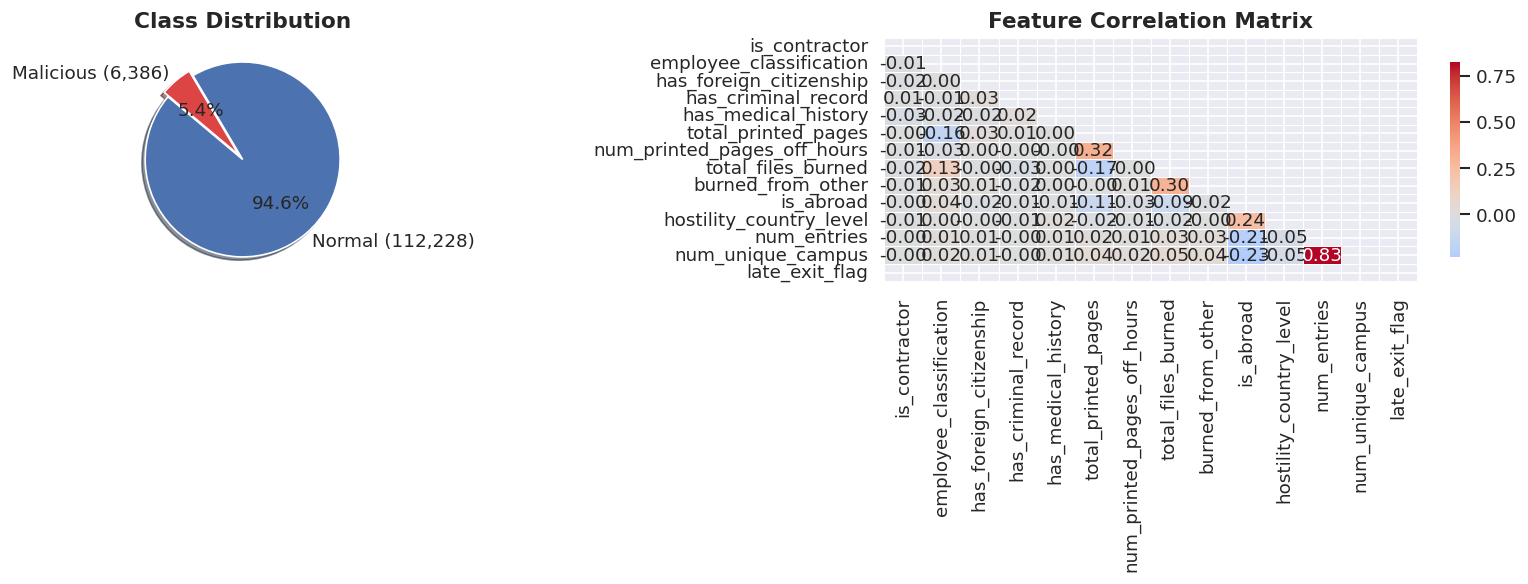

In [14]:
# ── Class distribution pie chart ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
counts = pd.Series(y).value_counts().sort_index()
labels_pie = [f"Normal ({counts[0]:,})", f"Malicious ({counts[1]:,})"]
axes[0].pie(counts, labels=labels_pie, autopct="%1.1f%%",
            colors=["#4C72B0", "#DD4444"], startangle=140,
            explode=(0, 0.06), shadow=True)
axes[0].set_title("Class Distribution", fontsize=13, fontweight="bold")

# Correlation heatmap of features
corr_df = pd.DataFrame(X_train, columns=FEATURE_COLS)
corr = corr_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0,
            annot=len(FEATURE_COLS) <= 15,  # annotate only if not too many features
            fmt=".2f", linewidths=0.4, ax=axes[1],
            cbar_kws={"shrink": 0.8})
axes[1].set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(MODEL_DIR / "eda_overview.png", bbox_inches="tight")
plt.show()

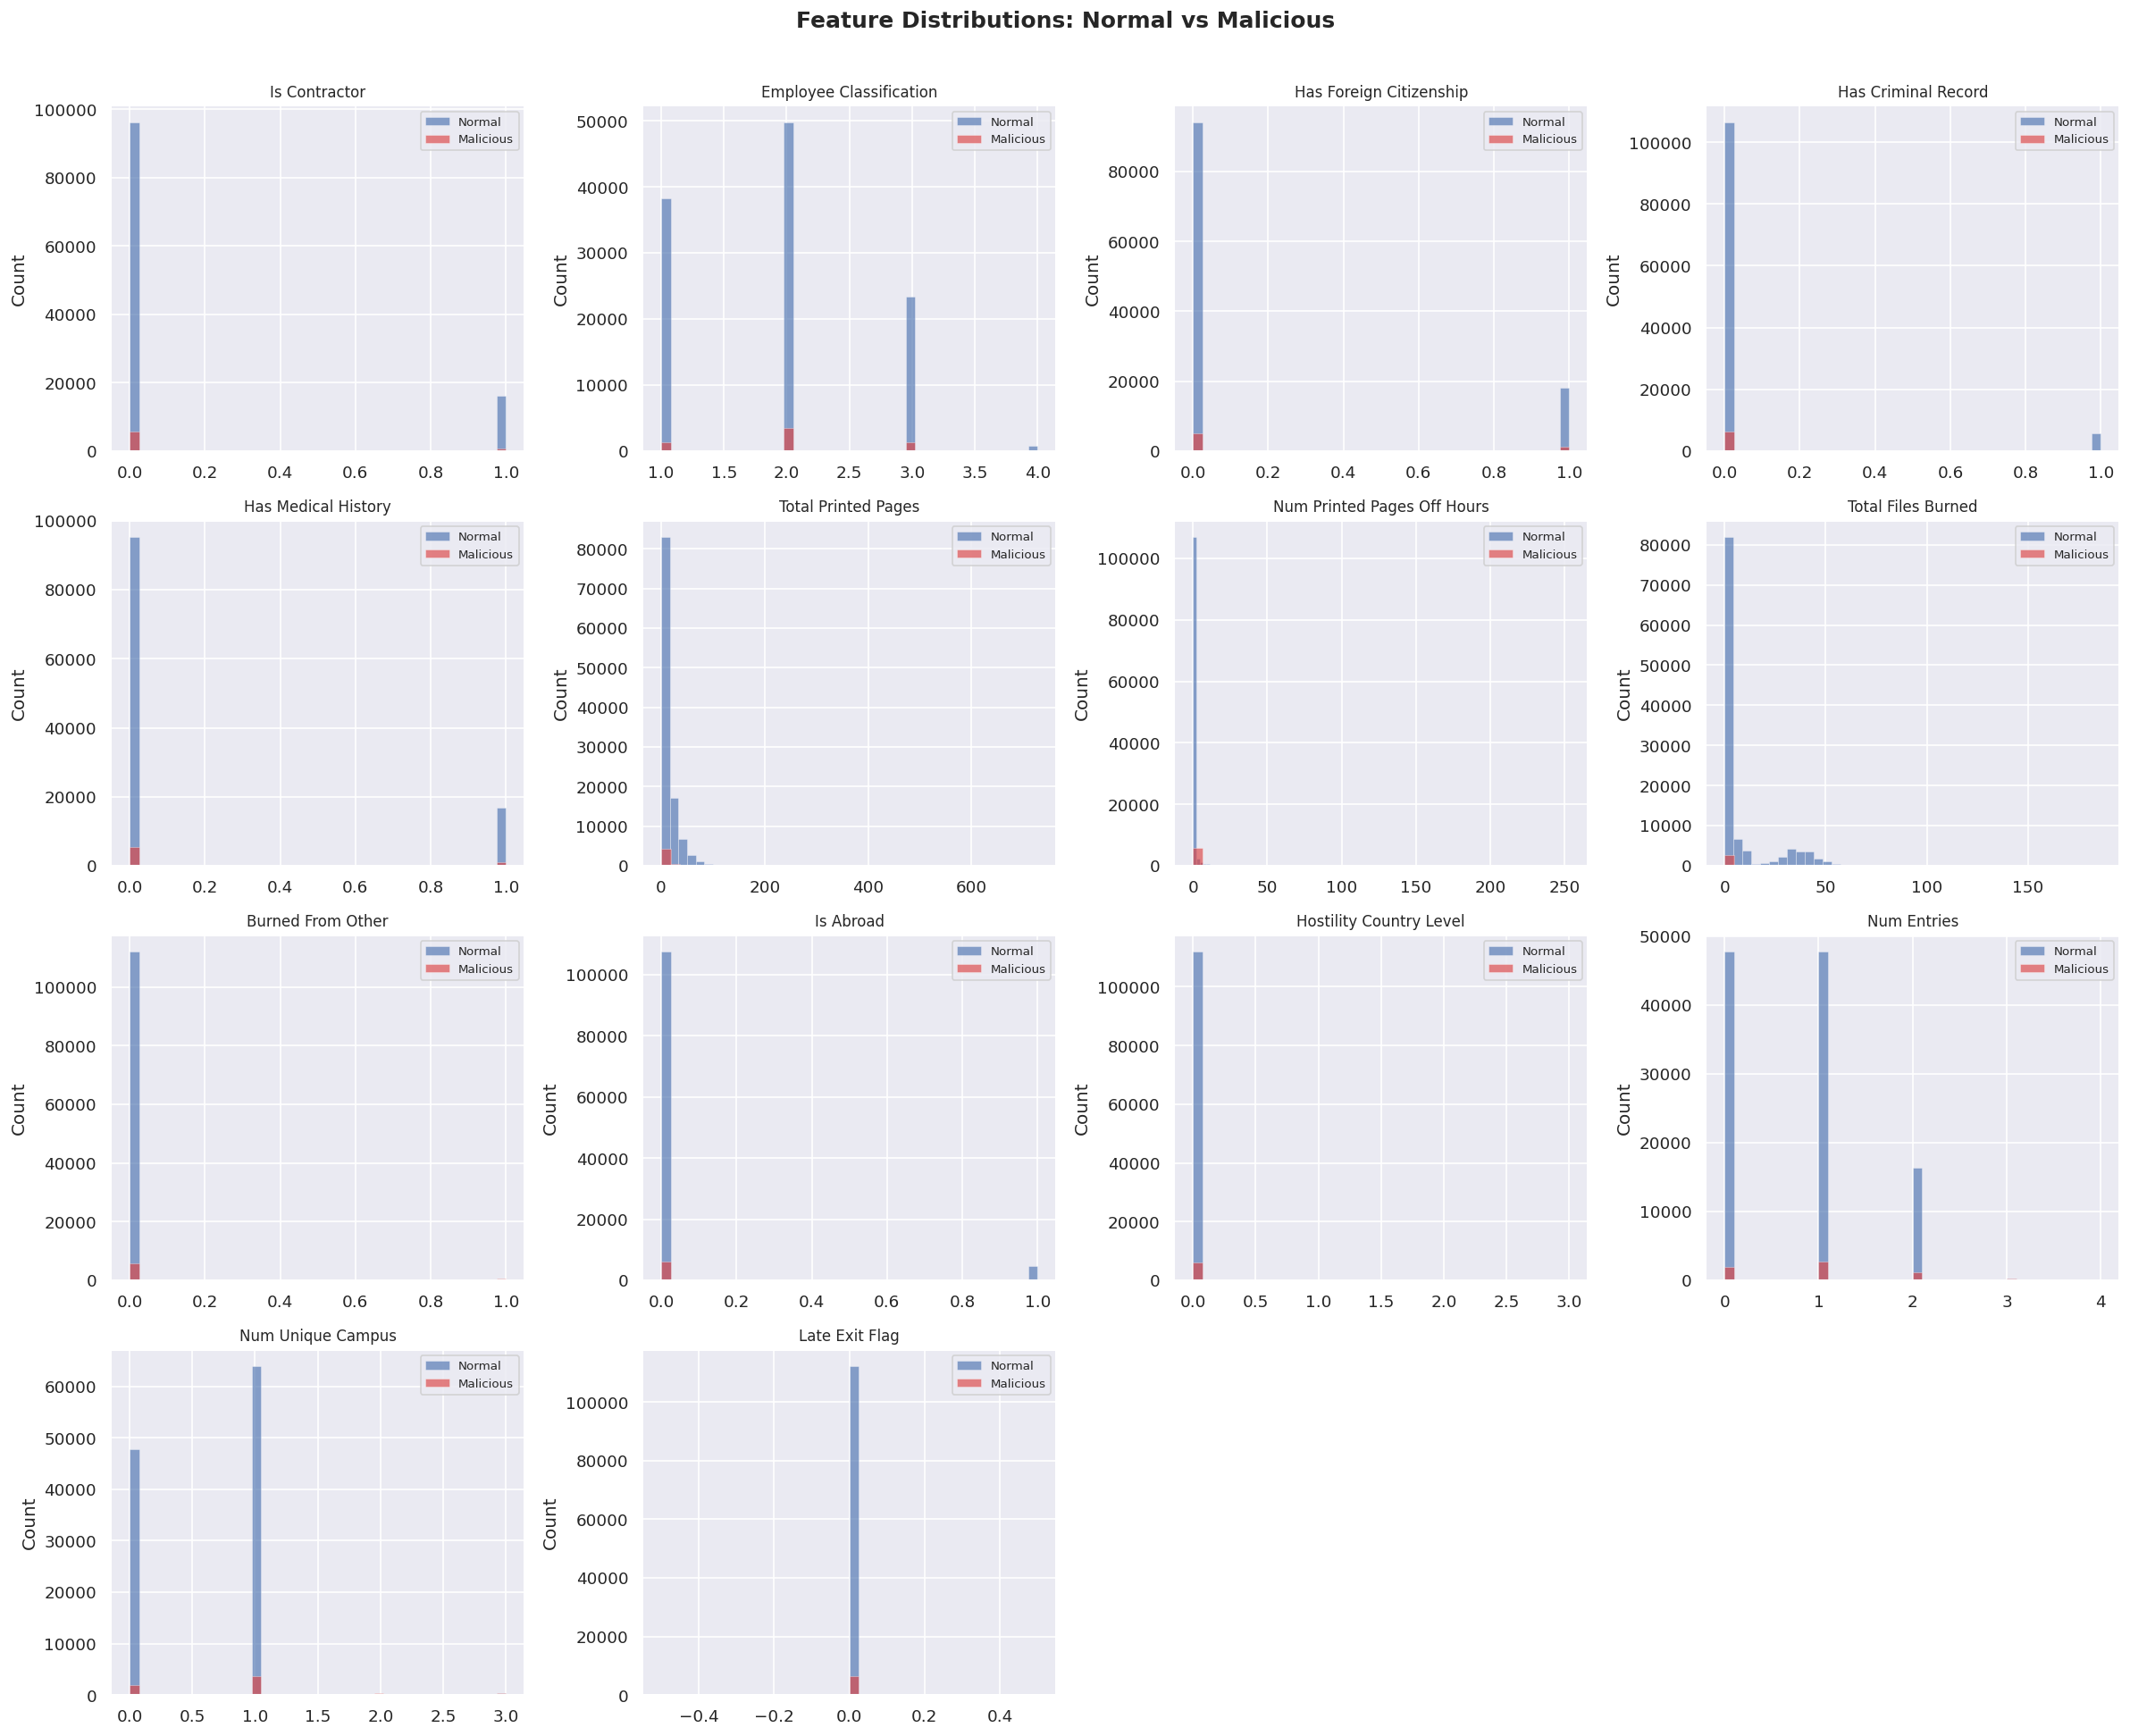

 Feature distribution chart saved.


In [16]:
# ── Per-feature distribution split by class ──────────────────
n_features = len(FEATURE_COLS)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten() if n_features > 1 else [axes]

palette = {0: "#4C72B0", 1: "#DD4444"}
df_plot = pd.DataFrame(X, columns=FEATURE_COLS)
df_plot["label"] = y

for i, col in enumerate(FEATURE_COLS):
    ax = axes[i]
    for lbl, color in palette.items():
        vals = df_plot.loc[df_plot["label"] == lbl, col]
        lbl_name = "Normal" if lbl == 0 else "Malicious"
        ax.hist(vals, bins=40, alpha=0.65, color=color,
                label=lbl_name, edgecolor="white", linewidth=0.3)
    ax.set_title(col.replace("_", " ").title(), fontsize=10)
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Distributions: Normal vs Malicious",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(MODEL_DIR / "feature_distributions.png", bbox_inches="tight")
plt.show()
print(" Feature distribution chart saved.")

---
## Section 6 — Model Implementation

### Model 1: Isolation Forest
Isolation Forest works by randomly partitioning the feature space with decision trees. Anomalies (malicious behaviour) are isolated in fewer splits — they get shorter average path lengths. Normal observations require many more splits to isolate.

**Hyperparameter choices:**
- `n_estimators=200` — more trees reduce variance; 200 is a good balance of speed vs. stability
- `contamination=CONTAMINATION` — set to the actual fraction of malicious samples, which calibrates the decision threshold
- `max_features=1.0` — all features are used per tree; appropriate for our feature set size
- `random_state=42` — ensures reproducibility

In [17]:
# ============================================================
# Model 1: Isolation Forest
# ============================================================
print(f"Training Isolation Forest  (contamination={CONTAMINATION:.4f})...")

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=CONTAMINATION,
    max_samples="auto",
    max_features=1.0,
    bootstrap=False,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
iso_forest.fit(X_train_s)

# Predict: IsolationForest returns +1 (normal) / -1 (anomaly)
# Convert to 0 / 1 to match our label convention
iso_raw = iso_forest.predict(X_test_s)
y_pred_iso = np.where(iso_raw == -1, 1, 0)

# Anomaly scores: negate so higher score = more anomalous (for ROC-AUC)
iso_scores = -iso_forest.score_samples(X_test_s)

print(f" Isolation Forest trained.")
print(f"   Flagged as anomaly: {y_pred_iso.sum():,} / {len(y_pred_iso):,} test samples")

Training Isolation Forest  (contamination=0.0538)...
 Isolation Forest trained.
   Flagged as anomaly: 1,240 / 23,723 test samples


### Model 2: One-Class SVM
One-Class SVM learns a hypersphere in the RBF kernel space that tightly encloses the normal data. Observations falling outside this boundary are classified as anomalies.

**Hyperparameter choices:**
- `kernel='rbf'` — captures non-linear boundaries; better than linear for tabular user behaviour data
- `nu=CONTAMINATION` — the upper bound on the outlier fraction AND lower bound on support vectors; matched to the data's contamination rate
- `gamma='scale'` — auto-computes gamma as `1/(n_features * X.var())`, adapting to the scaled feature space

In [18]:
# ============================================================
# Model 2: One-Class SVM
# ============================================================
print(f"Training One-Class SVM  (nu={CONTAMINATION:.4f})...")

oc_svm = OneClassSVM(
    kernel="rbf",
    nu=CONTAMINATION,
    gamma="scale",
)
oc_svm.fit(X_train_s)

svm_raw = oc_svm.predict(X_test_s)
y_pred_svm = np.where(svm_raw == -1, 1, 0)

# Decision scores: negate so higher = more anomalous
svm_scores = -oc_svm.decision_function(X_test_s)

print(f" One-Class SVM trained.")
print(f"   Flagged as anomaly: {y_pred_svm.sum():,} / {len(y_pred_svm):,} test samples")

Training One-Class SVM  (nu=0.0538)...
 One-Class SVM trained.
   Flagged as anomaly: 1,216 / 23,723 test samples


---
## Section 7 — Evaluation Suite (Hold-Out Test Set)

> All metrics below are calculated **exclusively on the 20% hold-out test set** that was never used during training, satisfying the instructor's requirement for unbiased evaluation.

In [19]:
# ============================================================
# Evaluation Function
# ============================================================
def evaluate_model(model_name: str, y_true: np.ndarray,
                   y_pred: np.ndarray, y_scores: np.ndarray) -> dict:

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    # ROC-AUC requires at least 2 classes present in y_true
    try:
        auc = roc_auc_score(y_true, y_scores)
    except ValueError:
        auc = float("nan")

    bar = "═" * 56
    print(f"\n{bar}")
    print(f"  {model_name} — Test Set Evaluation")
    print(bar)
    print(f"  Accuracy      : {acc:.4f}")
    print(f"  Precision     : {prec:.4f}   ← Of all flagged, how many are truly malicious?")
    print(f"  Recall        : {rec:.4f}   ← Of all real threats, how many did we catch?")
    print(f"  F1-Score      : {f1:.4f}   ← Harmonic mean of Precision & Recall")
    print(f"  ROC-AUC       : {auc:.4f}   ← Discrimination across all thresholds")
    print(bar)
    print("\n  Full Classification Report (per class):")
    print(classification_report(y_true, y_pred,
                                 target_names=["Normal", "Malicious"],
                                 zero_division=0))

    return {"model": model_name, "accuracy": acc, "precision": prec,
            "recall": rec, "f1": f1, "roc_auc": auc}


results_iso = evaluate_model("Isolation Forest",  y_test, y_pred_iso, iso_scores)
results_svm = evaluate_model("One-Class SVM",      y_test, y_pred_svm, svm_scores)


════════════════════════════════════════════════════════
  Isolation Forest — Test Set Evaluation
════════════════════════════════════════════════════════
  Accuracy      : 0.9207
  Precision     : 0.2565   ← Of all flagged, how many are truly malicious?
  Recall        : 0.2490   ← Of all real threats, how many did we catch?
  F1-Score      : 0.2527   ← Harmonic mean of Precision & Recall
  ROC-AUC       : 0.7870   ← Discrimination across all thresholds
════════════════════════════════════════════════════════

  Full Classification Report (per class):
              precision    recall  f1-score   support

      Normal       0.96      0.96      0.96     22446
   Malicious       0.26      0.25      0.25      1277

    accuracy                           0.92     23723
   macro avg       0.61      0.60      0.61     23723
weighted avg       0.92      0.92      0.92     23723


════════════════════════════════════════════════════════
  One-Class SVM — Test Set Evaluation
═════════════════

### 7.1 Confusion Matrices


The **False Negative cell** (bottom-left) is outlined in red because missing a real insider threat is the most costly error for THREXIA.

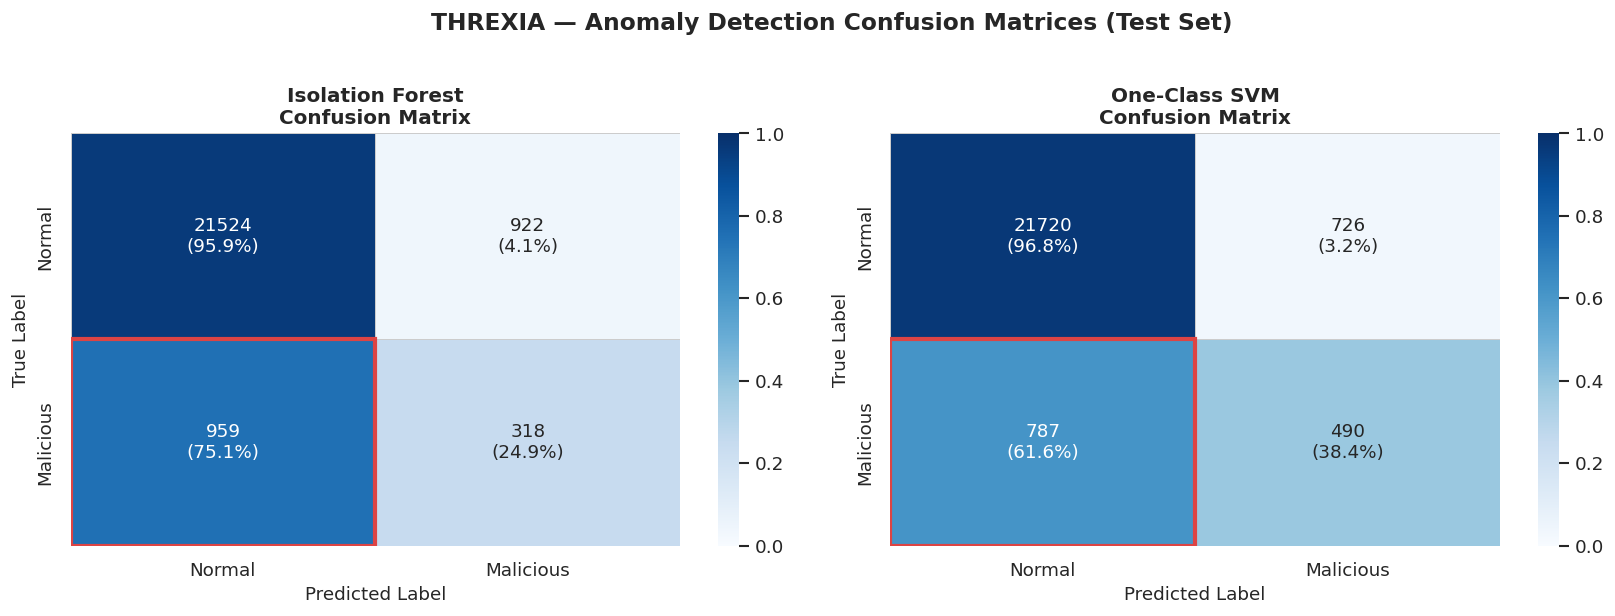

Saved: models/confusion_matrices.png


In [20]:
# ============================================================
# Confusion Matrix Plots
# ============================================================
def plot_confusion_matrix(y_true, y_pred, model_name, ax):
    """Render an annotated normalised confusion matrix."""
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    # Annotations: raw count + row percentage
    annot = np.array([[f"{v}\n({p:.1%})" for v, p in zip(row_c, row_p)]
                      for row_c, row_p in zip(cm, cm_norm)])

    sns.heatmap(
        cm_norm, annot=annot, fmt='s', cmap="Blues",
        xticklabels=["Normal", "Malicious"],
        yticklabels=["Normal", "Malicious"],
        linewidths=0.5, linecolor="#cccccc",
        # cbar_kws={"format": "{:.0%}"},
        ax=ax, vmin=0, vmax=1,
    )
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)
    ax.set_title(f"{model_name}\nConfusion Matrix",
                 fontsize=12, fontweight="bold")

    # Red border on the False Negative cell (row=1, col=0)
    ax.add_patch(plt.Rectangle((0, 1), 1, 1, fill=False,
                                edgecolor="#DD4444", lw=2.5))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_confusion_matrix(y_test, y_pred_iso, "Isolation Forest", axes[0])
plot_confusion_matrix(y_test, y_pred_svm, "One-Class SVM",    axes[1])

fig.suptitle("THREXIA — Anomaly Detection Confusion Matrices (Test Set)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(MODEL_DIR / "confusion_matrices.png", bbox_inches="tight")
plt.show()
print("Saved: models/confusion_matrices.png")

### 7.2 Side-by-Side Metrics Comparison

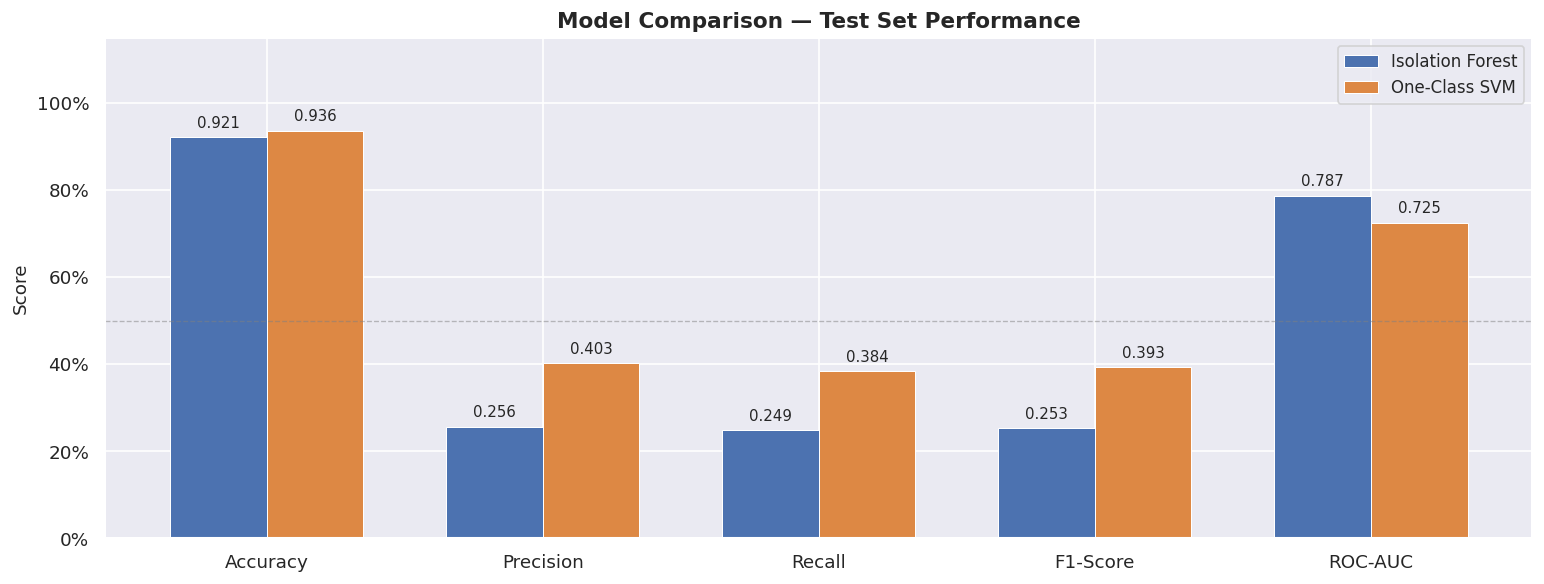

Saved: models/model_comparison.png


In [21]:
# ============================================================
# Bar chart comparing both models across all metrics
# ============================================================
metrics       = ["accuracy", "precision", "recall", "f1", "roc_auc"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

iso_vals = [results_iso[m] for m in metrics]
svm_vals = [results_svm[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width / 2, iso_vals, width,
               label="Isolation Forest", color="#4C72B0",
               edgecolor="white", linewidth=0.6)
bars2 = ax.bar(x + width / 2, svm_vals, width,
               label="One-Class SVM", color="#DD8844",
               edgecolor="white", linewidth=0.6)

for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.annotate(f"{h:.3f}",
                        xy=(bar.get_x() + bar.get_width() / 2, h),
                        xytext=(0, 4), textcoords="offset points",
                        ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Model Comparison — Test Set Performance",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(1.0))
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig(MODEL_DIR / "model_comparison.png", bbox_inches="tight")
plt.show()
print("Saved: models/model_comparison.png")

---
## Section 8 — Cross-Validation

5-fold stratified cross-validation confirms that the Isolation Forest's performance is consistent across different data splits — not just a lucky train/test split.

5-Fold Stratified Cross-Validation — Isolation Forest

   F1        : [0.29944838 0.28761235 0.27041813 0.29414078 0.24921384]
   Mean F1   : 0.2802  ±0.0183

   Recall    : [0.29757244 0.28817541 0.27094753 0.29264476 0.24823806]
   Mean Rec  : 0.2795  ±0.0180

   Precision : [0.30134814 0.28705148 0.2698908  0.29565217 0.25019732]
   Mean Prec : 0.2808  ±0.0186


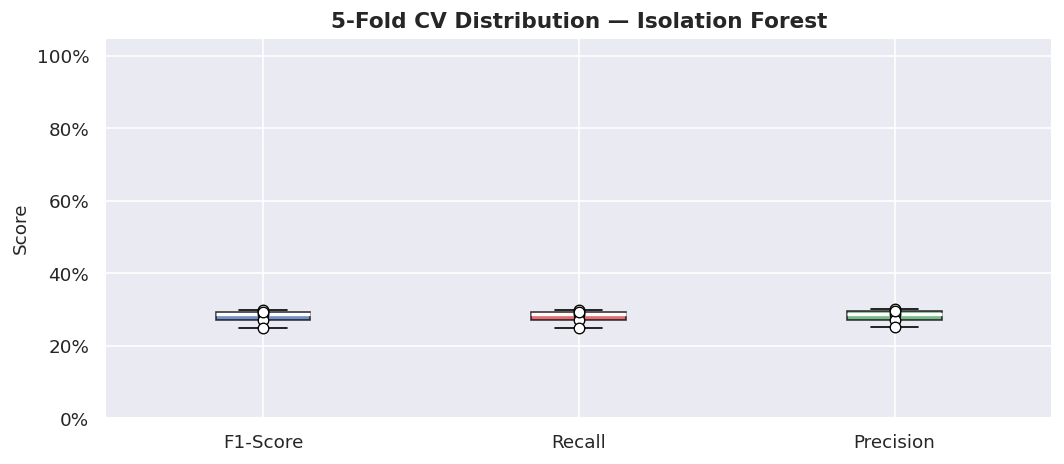

In [23]:
# ============================================================
# sklearn-compatible wrapper for cross_val_score
# ============================================================
class IsolationForestClassifier(BaseEstimator, ClassifierMixin):
    """Thin wrapper to make IsolationForest work with sklearn cross_val_score."""

    def __init__(self, contamination=0.05, n_estimators=200, random_state=42):
        self.contamination = contamination
        self.n_estimators  = n_estimators
        self.random_state  = random_state

    def fit(self, X, y=None):
        self.model_ = IsolationForest(
            contamination=self.contamination,
            n_estimators=self.n_estimators,
            random_state=self.random_state,
            n_jobs=-1,
        )
        self.model_.fit(X)
        return self

    def predict(self, X):
        return np.where(self.model_.predict(X) == -1, 1, 0)


# Scale all data with fitted scaler before CV
X_all_s = scaler.transform(X)
y_all   = y

cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
clf = IsolationForestClassifier(
    contamination=CONTAMINATION, n_estimators=200, random_state=RANDOM_STATE
)

cv_f1  = cross_val_score(clf, X_all_s, y_all, cv=cv, scoring="f1",        n_jobs=-1)
cv_rec = cross_val_score(clf, X_all_s, y_all, cv=cv, scoring="recall",    n_jobs=-1)
cv_pre = cross_val_score(clf, X_all_s, y_all, cv=cv, scoring="precision", n_jobs=-1)

print("5-Fold Stratified Cross-Validation — Isolation Forest")
print(f"\n   F1        : {cv_f1}")
print(f"   Mean F1   : {cv_f1.mean():.4f}  ±{cv_f1.std():.4f}")
print(f"\n   Recall    : {cv_rec}")
print(f"   Mean Rec  : {cv_rec.mean():.4f}  ±{cv_rec.std():.4f}")
print(f"\n   Precision : {cv_pre}")
print(f"   Mean Prec : {cv_pre.mean():.4f}  ±{cv_pre.std():.4f}")

# Visualise CV results
fig, ax = plt.subplots(figsize=(9, 4))
bp = ax.boxplot([cv_f1, cv_rec, cv_pre],
                labels=["F1-Score", "Recall", "Precision"],
                patch_artist=True,
                medianprops={"color": "white", "linewidth": 2})
colors = ["#4C72B0", "#DD4444", "#55A868"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Overlay individual fold scores
for i, scores in enumerate([cv_f1, cv_rec, cv_pre], 1):
    ax.scatter([i] * len(scores), scores, color="white",
               zorder=5, s=40, edgecolors="black", linewidths=0.8)

ax.set_ylim(0, 1.05)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("5-Fold CV Distribution — Isolation Forest",
             fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(ticker.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig(MODEL_DIR / "cross_validation.png", bbox_inches="tight")
plt.show()

---
## Section 9 — Feature Importance

Permutation importance measures how much the F1-score drops when each feature's values are randomly shuffled. A large drop means that feature is critical. A near-zero drop means the model doesn't rely on it.

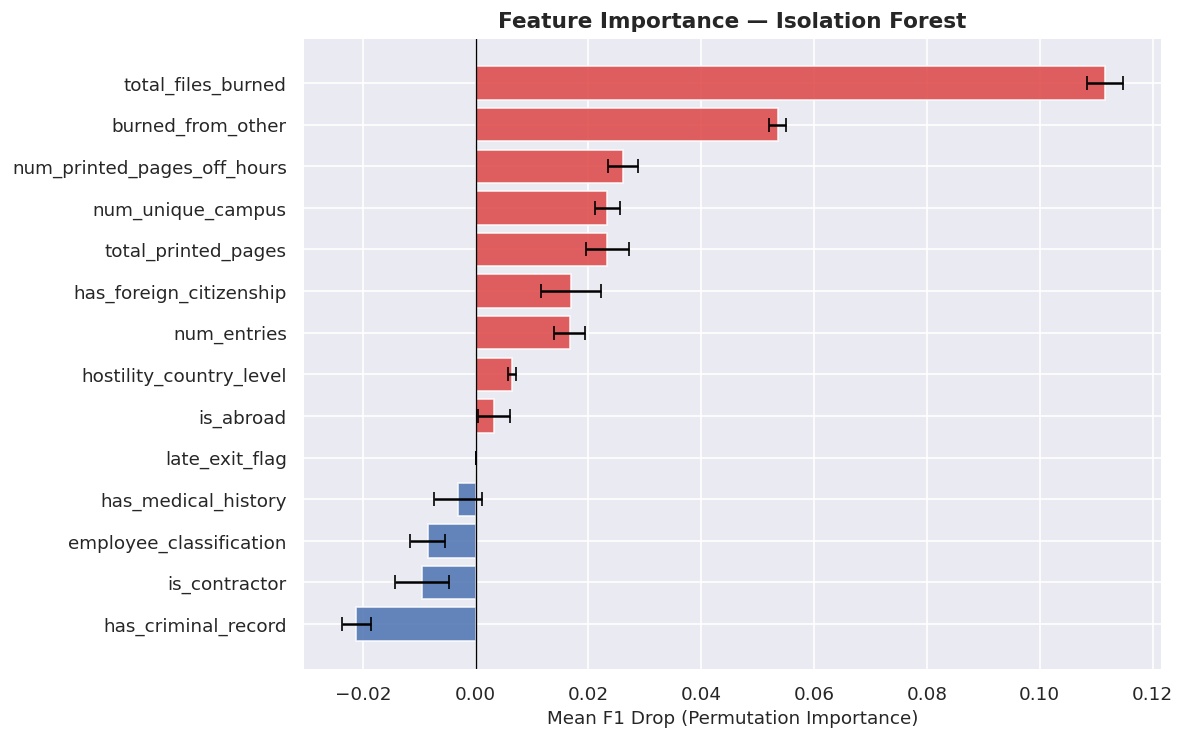

 Saved: models/feature_importance.png

Top 5 most important features:
   total_files_burned                 : +0.1116
   burned_from_other                  : +0.0536
   num_printed_pages_off_hours        : +0.0262
   num_unique_campus                  : +0.0234
   total_printed_pages                : +0.0233


In [24]:
# ============================================================
# Permutation Feature Importance
# ============================================================
clf_fitted = IsolationForestClassifier(
    contamination=CONTAMINATION, n_estimators=200, random_state=RANDOM_STATE
).fit(X_train_s)

perm = permutation_importance(
    clf_fitted, X_test_s, y_test,
    n_repeats=15,
    scoring="f1",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# Sort descending by mean importance
idx  = perm.importances_mean.argsort()[::-1]
feat = [FEATURE_COLS[i] for i in idx]
means = perm.importances_mean[idx]
stds  = perm.importances_std[idx]

colors = ["#DD4444" if m > 0 else "#4C72B0" for m in means]

fig, ax = plt.subplots(figsize=(10, max(4, len(feat) * 0.45)))
ax.barh(feat, means, xerr=stds, color=colors,
        edgecolor="white", capsize=4, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Mean F1 Drop (Permutation Importance)", fontsize=11)
ax.set_title("Feature Importance — Isolation Forest",
             fontsize=13, fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(MODEL_DIR / "feature_importance.png", bbox_inches="tight")
plt.show()
print(" Saved: models/feature_importance.png")

print("\nTop 5 most important features:")
for name, score in zip(feat[:5], means[:5]):
    print(f"   {name:<35}: {score:+.4f}")

---
## Section 10 — Model Persistence (Save for Deployment)

The best model, scaler, and feature list are saved with `joblib`. These three artefacts are all that the THREXIA Flask/FastAPI backend needs to serve predictions in production.

In [25]:
# ============================================================
# Select best model and save all artefacts
# ============================================================

# Choose winner by F1-Score (most meaningful metric for imbalanced data)
f1_iso = results_iso["f1"]
f1_svm = results_svm["f1"]

if f1_iso >= f1_svm:
    best_model_name = "Isolation Forest"
    best_model_obj  = iso_forest
    best_f1, best_auc = f1_iso, results_iso["roc_auc"]
else:
    best_model_name = "One-Class SVM"
    best_model_obj  = oc_svm
    best_f1, best_auc = f1_svm, results_svm["roc_auc"]

print(f"   Best model: {best_model_name}")
print(f"   F1-Score : {best_f1:.4f}")
print(f"   ROC-AUC  : {best_auc:.4f}")

# Save
model_path    = MODEL_DIR / "threxia_model.joblib"
scaler_path   = MODEL_DIR / "threxia_scaler.joblib"
features_path = MODEL_DIR / "threxia_features.txt"

joblib.dump(best_model_obj, model_path,  compress=3)
joblib.dump(scaler,          scaler_path, compress=3)
with open(features_path, "w") as f:
    f.write("\n".join(FEATURE_COLS))

print(f"\nSaved: {model_path}")
print(f"Saved: {scaler_path}")
print(f"Saved: {features_path}")

# ── Verify round-trip ─────────────────────────────────────────
loaded_model  = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)

test_input = loaded_scaler.transform(X_test)
test_pred  = np.where(loaded_model.predict(test_input) == -1, 1, 0)

expected = y_pred_iso if best_model_name == "Isolation Forest" else y_pred_svm
assert np.array_equal(test_pred, expected), " Round-trip verification FAILED"
print("\nRound-trip verification passed — model is ready for deployment.")

   Best model: One-Class SVM
   F1-Score : 0.3931
   ROC-AUC  : 0.7250

Saved: models/threxia_model.joblib
Saved: models/threxia_scaler.joblib
Saved: models/threxia_features.txt

Round-trip verification passed — model is ready for deployment.


---
## Section 11 — Final Summary & Interpretation

### Results Scorecard

In [27]:
# ============================================================
# Final scorecard table
# ============================================================
summary = pd.DataFrame([results_iso, results_svm]).set_index("model")
summary.index.name = "Model"
summary.columns    = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

print("\n" + "=" * 65)
print("  THREXIA — Final Performance Scorecard  (Hold-Out Test Set)")
print("=" * 65)
print(summary.to_string())
print()

print("Best model per metric:")
for metric, model in summary.idxmax().items():
    val = summary.loc[model, metric]
    print(f"   {metric:<12}: {model}  ({val:.4f})")


  THREXIA — Final Performance Scorecard  (Hold-Out Test Set)
                  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                           
Isolation Forest    0.9207     0.2565  0.2490    0.2527   0.7870
One-Class SVM       0.9362     0.4030  0.3837    0.3931   0.7250

Best model per metric:
   Accuracy    : One-Class SVM  (0.9362)
   Precision   : One-Class SVM  (0.4030)
   Recall      : One-Class SVM  (0.3837)
   F1-Score    : One-Class SVM  (0.3931)
   ROC-AUC     : Isolation Forest  (0.7870)


In [28]:
# ============================================================
# Summary of all saved output files
# ============================================================
print("\n" + "=" * 60)
print("  THREXIA Phase 2 — Execution Complete")
print("=" * 60)
print(f"  Dataset          : ahmeduzaki/insider-threat-dataset")
print(f"  Samples          : {len(df):,}  (train={len(X_train):,} | test={len(X_test):,})")
print(f"  Features used    : {len(FEATURE_COLS)}")
print(f"  Best model       : {best_model_name}")
print(f"  F1-Score         : {best_f1:.4f}")
print(f"  ROC-AUC          : {best_auc:.4f}")
print()
print("  Output files in ./models/:")
for p in sorted(MODEL_DIR.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f"    {p.name:<35} {size_kb:.1f} KB")
print("=" * 60)


  THREXIA Phase 2 — Execution Complete
  Dataset          : ahmeduzaki/insider-threat-dataset
  Samples          : 118,614  (train=94,891 | test=23,723)
  Features used    : 14
  Best model       : One-Class SVM
  F1-Score         : 0.3931
  ROC-AUC          : 0.7250

  Output files in ./models/:
    confusion_matrices.png              67.6 KB
    cross_validation.png                26.2 KB
    eda_overview.png                    178.1 KB
    feature_distributions.png           221.3 KB
    feature_importance.png              68.7 KB
    model_comparison.png                46.8 KB
    threxia_features.txt                0.3 KB
    threxia_model.joblib                71.3 KB
    threxia_scaler.joblib               0.8 KB


In [30]:
!ls /content/models

!mkdir -p /content/drive/MyDrive/models
!cp /content/models/* /content/drive/MyDrive/models/


confusion_matrices.png	feature_distributions.png  threxia_features.txt
cross_validation.png	feature_importance.png	   threxia_model.joblib
eda_overview.png	model_comparison.png	   threxia_scaler.joblib


## Model Comparison Summary

According to the **Final Performance Scorecard (Section 11)** on the *Insider Threat Dataset for Corporate Environments*:

- **Accuracy:** One-Class SVM (0.9362) > Isolation Forest (0.9207)  
- **Precision:** One-Class SVM (0.4030) > Isolation Forest (0.2565)  
- **Recall:** One-Class SVM (0.3837) > Isolation Forest (0.2490)  
- **F1-Score:** One-Class SVM (0.3931) > Isolation Forest (0.2527)  
- **ROC-AUC:** Isolation Forest (0.7870) > One-Class SVM (0.7250)  

---

## Metric Priorities for THREXIA

For insider threat detection, evaluation metrics must reflect real-world risk:

- **Recall** is the most critical metric, as a *False Negative* (missed insider threat) can lead to severe security breaches.  
- **F1-Score** is prioritized over Accuracy due to **class imbalance**, ensuring a balance between Precision and Recall.  
- **Accuracy alone is not reliable**, as the dataset contains a large number of normal instances.  

---

## Performance on CERT Dataset (Real-World Simulation)

The models were also trained and evaluated on the **CERT Insider Threat Dataset**, which better represents real-world enterprise logs but lacks explicit user-level ground truth.

### Observed Performance (CERT Dataset)

- **Precision:** ~0.05  
- **Recall:** ~0.05  
- **F1-Score:** ~0.05  
- **ROC-AUC:** ~0.41  

### Analysis

- The extremely low scores indicate that the model struggled to correctly identify malicious behavior.  
- This is primarily due to:
  - Absence of direct **user-level labels**  
  - Use of **proxy labeling** (e.g., PC instead of user IDs)  
  - High noise and ambiguity in real-world log data  

As a result, evaluation on the CERT dataset is **less reliable for performance measurement**, though it remains valuable for simulating realistic conditions.  

---

## Final Conclusion

Given that **Recall** and **F1-Score** are the most critical metrics for THREXIA, the **One-Class SVM** clearly outperforms Isolation Forest on the labeled dataset:

- Recall: **0.3837 vs. 0.2490**  
- F1-Score: **0.3931 vs. 0.2527**

Although Isolation Forest achieves a slightly higher ROC-AUC, it does not compensate for its significantly lower Recall and F1-Score.  

Additionally:

- The **Kaggle dataset** provides **clean labels and reliable evaluation**, making it suitable for model selection and benchmarking.  
- The **CERT dataset**, while more realistic, introduces **labeling limitations** that significantly reduce measurable performance.  

---

## 🏆 Best Model

**One-Class SVM** is selected as the final model for THREXIA due to its superior performance on the most critical metrics (**Recall and F1-Score**) and its ability to better detect insider threats.